In [ ]:
!pip install scikit-surprise pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 6.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554979 sha256=3adebaccae3a3249330469c30cb19c59143146295ea07f31e50c8e3cd1564a9d
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [12]:
import pandas as pd

In [17]:
movies = pd.read_csv(r'/content/movies.csv')
tags = pd.read_csv(r'/content/tags.csv')
ratings = pd.read_csv(r'/content/ratings.csv')
links = pd.read_csv(r'/content/links.csv')

In [18]:
# replaces this '|' with ' '
movies['genres'] = movies['genres'].str.replace('|', ' ')

In [19]:
print("tags " , tags.isnull().sum(), '\n')
print("ratings ", ratings.isnull().sum(), '\n')
print("links ", links.isnull().sum(), '\n')
print("movies ", movies.isnull().sum())

tags  userId       0
movieId      0
tag          0
timestamp    0
dtype: int64 

ratings  userId       0
movieId      0
rating       0
timestamp    0
dtype: int64 

links  movieId    0
imdbId     0
tmdbId     8
dtype: int64 

movies  movieId    0
title      0
genres     0
dtype: int64


In [20]:
data = pd.merge(ratings, movies, on='movieId')

In [21]:
tags_grouped = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()

Combines all tags of a movie into one string like , ->      
1 funny, 1 animation, 1 comedy -> 1 | "funny animation kids",             
groupby('movieId') → group rows by movie ,['tag'] → select tag column ,' '.join(x) → combine tags into one sentence , reset_index() → convert back to DataFrame

In [22]:
movies = movies.merge(tags_grouped, on='movieId', how='left')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Adds tags to movies dataset, how='left' => Keeps ALL movies, Even if: some movies have no tags

In [23]:
movies['combined'] = (movies['genres'] * 2) + ' ' + movies['tag'].fillna('')

Creates a single text column for ML model, why genres * 2 because it gives more importance to genres

In [24]:
movie_matrix = data.pivot_table(index='userId', columns='title', values='rating')

why matrix because we need this format to train the model, model can easily understand data like in this way

In [25]:
movie_matrix = movie_matrix.subtract(movie_matrix.mean(axis=1), axis=0)

Calculate average rating per user then Subtract mean from each row,  
axis=1 (in mean) -> Calculate mean across columns (movies), axis=1 (in mean) -> Calculate mean across columns (movies)

In [26]:
movie_matrix = movie_matrix.fillna(0) #make NaN to 0

In [27]:
print(movie_matrix)

title   '71 (2014)  'Hellboy': The Seeds of Creation (2004)  \
userId                                                        
1         0.000000                                      0.0   
2         0.000000                                      0.0   
3         0.000000                                      0.0   
4         0.000000                                      0.0   
5         0.000000                                      0.0   
...            ...                                      ...   
606       0.000000                                      0.0   
607       0.000000                                      0.0   
608       0.000000                                      0.0   
609       0.000000                                      0.0   
610       0.311444                                      0.0   

title   'Round Midnight (1986)  'Salem's Lot (2004)  \
userId                                                
1                          0.0                  0.0   
2              

Build Content-Based Model below

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies['combined']) #train the tfidf model from movies['combined']

In [30]:
# similarity = cosine_similarity(movie_matrix.T) # Why .T? We compare movies with movies, not users
cosine_sim = cosine_similarity(tfidf_matrix)

Because:
movie_matrix = users × movies
After .T → movies × users

why cosine_similarity Because we want to measure: “How similar are two movies based on user ratings?”

cosine_similarity ->
Computes similarity for ALL movies
Stores full similarity matrix
Simple but heavy for large datasets

KNN approach ->
Finds only top K neighbors
More efficient for big data
Used in real-world systems

In [31]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

Creates a mapping from movie title → row index , index=movies['title'] -> Make movie titles the labels,

In [32]:
# def recommend_movies(movie_name):
#     similar_scores = similarity_df[movie_name].sort_values(ascending=False)
#     return similar_scores[1:6]  # top 5 movies
def recommend_content(movie_name):
    if movie_name not in indices:
        return "Movie not found"

    idx = indices[movie_name]
    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:6]

    movie_indices = [i[0] for i in sim_scores]

    result = movies['title'].iloc[movie_indices]

    print(f"{movie_name}")
    print(f"Genres -> {movies.iloc[idx]['genres']}")

    for i, movie in enumerate(result, 1):
        print(f"{i}. {movie}")

    # return movies['title'].iloc[movie_indices].tolist()

In [33]:
recommend_content('Toy Story (1995)')

Toy Story (1995)
Genres -> Adventure Animation Children Comedy Fantasy
1. Bug's Life, A (1998)
2. Toy Story 2 (1999)
3. Antz (1998)
4. Adventures of Rocky and Bullwinkle, The (2000)
5. Emperor's New Groove, The (2000)


In [34]:
recommend_content("Wolf of Wall Street, The (2013)")

Wolf of Wall Street, The (2013)
Genres -> Comedy Crime Drama
1. Departed, The (2006)
2. Shutter Island (2010)
3. Doom Generation, The (1995)
4. Jimmy Hollywood (1994)
5. Fried Green Tomatoes (1991)


visualisation

In [35]:
import matplotlib.pyplot as plt

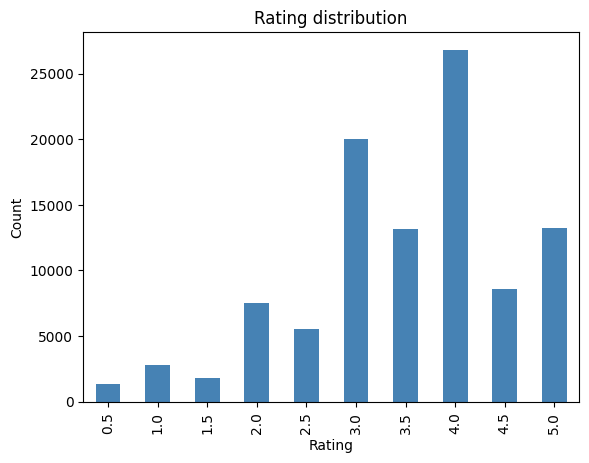

In [36]:
# 1. Rating distribution
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating distribution'); plt.xlabel('Rating'); plt.ylabel('Count'); plt.show()

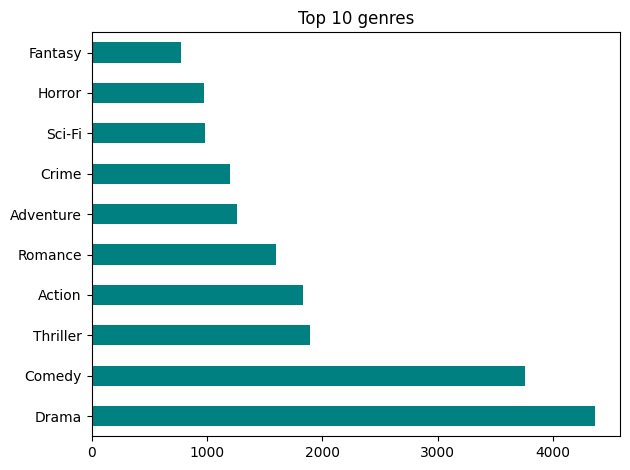

In [37]:
# 2. Top 10 genres by movie count
from collections import Counter
all_genres = ' '.join(movies['genres']).split()
genre_counts = Counter(all_genres)
pd.Series(genre_counts).nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 genres'); plt.tight_layout(); plt.show()

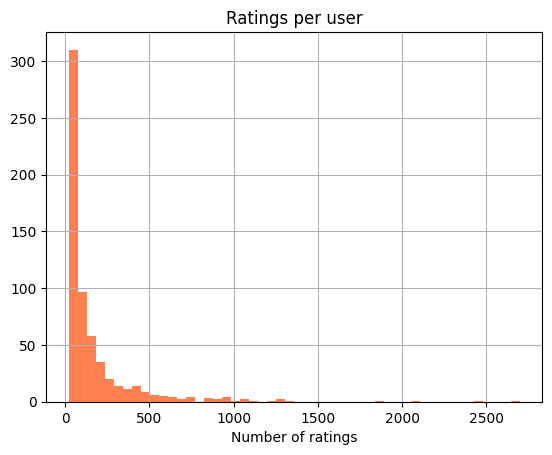

In [38]:
# 3. Ratings per user (distribution)
ratings.groupby('userId')['rating'].count().hist(bins=50, color='coral')
plt.title('Ratings per user'); plt.xlabel('Number of ratings'); plt.show()

In [ ]:
!pip uninstall -y numpy scipy scikit-surprise
!pip install numpy==1.26.4 scipy==1.11.4
!pip install scikit-surprise --no-deps

Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.5 MB/s eta 0:00:00
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 14.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0,

  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl


Add Collaborative Filtering (SVD)

In [ ]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 11.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554970 sha256=1e4db4eb7db1eee61ebcb00288c33f6a442c9a3b749a97ea3f4f6460e4dd6eab
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
from surprise import Dataset, Reader, SVD

In [ ]:
#prepare data
reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

In [ ]:
from surprise.model_selection import train_test_split

In [ ]:
trainset, testset = train_test_split(data, test_size=0.2)

In [ ]:
# train model
svd_model = SVD()
svd_model.fit(trainset)

In [ ]:
# predictions
predictions = svd_model.test(testset)

In [ ]:
from surprise import accuracy

In [ ]:
# RMSE
rmse = accuracy.rmse(predictions)

RMSE: 0.8720


In [ ]:
from surprise.model_selection import cross_validate

In [ ]:
cross_validate(SVD(), data, measures=['RMSE'], cv=5, verbose=True)

Evaluating RMSE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8676  0.8702  0.8856  0.8776  0.8644  0.8731  0.0076  
Fit time          2.26    1.39    1.41    1.38    1.38    1.56    0.35    
Test time         0.35    0.11    0.11    0.26    0.13    0.19    0.10    


{'test_rmse': array([0.86762174, 0.87021537, 0.88555517, 0.87763109, 0.86438891]),
 'fit_time': (2.2564361095428467,
  1.390618085861206,
  1.412189245223999,
  1.378951072692871,
  1.3758807182312012),
 'test_time': (0.3541221618652344,
  0.10592889785766602,
  0.10532474517822266,
  0.2591865062713623,
  0.13046002388000488)}

In [ ]:
from collections import defaultdict

def precision_at_k(predictions, k=5, threshold=3.5):
    user_est_true = defaultdict(list)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = {}

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        relevant = sum((true_r >= threshold) for (_, true_r) in top_k)
        recommended = sum((est >= threshold) for (est, _) in top_k)

        precisions[uid] = relevant / recommended if recommended != 0 else 0

    return sum(precisions.values()) / len(precisions)

print("Precision@5:", precision_at_k(predictions))

Precision@5: 0.8998633879781431


SQL SECTION

In [ ]:
import sqlite3

conn = sqlite3.connect("movies.db")

ratings.to_sql("ratings", conn, if_exists="replace", index=False)
movies.to_sql("movies", conn, if_exists="replace", index=False)

9742

In [ ]:
pd.read_sql("""
SELECT movieId, AVG(rating) as avg_rating
FROM ratings
GROUP BY movieId
ORDER BY avg_rating DESC
LIMIT 10
""", conn)

,movieId,avg_rating
0,187717,5.0
1,184245,5.0
2,179135,5.0
3,179133,5.0
4,176601,5.0
5,175431,5.0
6,175397,5.0
7,175387,5.0
8,175293,5.0
9,174551,5.0


In [ ]:
pd.read_sql("""
SELECT userId, COUNT(*) as total_ratings
FROM ratings
GROUP BY userId
ORDER BY total_ratings DESC
""", conn)

,userId,total_ratings
0,414,2698
1,599,2478
2,474,2108
3,448,1864
4,274,1346
...,...,...
605,207,20
606,194,20
607,189,20
608,147,20


In [ ]:
pd.read_sql("""
SELECT movieId, COUNT(*) as num_ratings
FROM ratings
GROUP BY movieId
ORDER BY num_ratings DESC
LIMIT 10
""", conn)

,movieId,num_ratings
0,356,329
1,318,317
2,296,307
3,593,279
4,2571,278
5,260,251
6,480,238
7,110,237
8,589,224
9,527,220


In [ ]:
pd.read_sql("""
SELECT m.title, AVG(r.rating) as avg_rating
FROM movies m
JOIN ratings r ON m.movieId = r.movieId
GROUP BY m.title
ORDER BY avg_rating DESC
LIMIT 10
""", conn)

,title,avg_rating
0,Zeitgeist: Moving Forward (2011),5.0
1,Wow! A Talking Fish! (1983),5.0
2,World of Glory (1991),5.0
3,Wonder Woman (2009),5.0
4,Won't You Be My Neighbor? (2018),5.0
5,"Woman Under the Influence, A (1974)",5.0
6,"Woman Is a Woman, A (femme est une femme, Une)...",5.0
7,Winter in Prostokvashino (1984),5.0
8,Winnie the Pooh and the Day of Concern (1972),5.0
9,Winnie the Pooh Goes Visiting (1971),5.0


Creating FINAL PIPELINE OBJECT

In [ ]:
model_data = {
    "movies": movies,
    "cosine_sim": cosine_sim,
    "indices": indices,
    "svd_model": svd_model
}

In [ ]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model_data, f)